# 🪄 11-02 · 指数平滑：轻量递推预测

> 目标：最实用的"轻模型"。手写 **SES、Holt（趋势）、Holt-Winters（季节）**，
> 用网格搜索定超参，最后给预测加置信区间。

> 🧩 **生活化类比**：指数平滑 = "带记忆的加权平均"——最近的数据权重最大，
> 老数据指数级衰减。Holt 加"惯性"（趋势），Holt-Winters 再加"日历"（季节）。


## 1. SES：简单指数平滑

$$\\hat y_{t+1} = \\alpha y_t + (1-\\alpha) \\hat y_t$$

- 展开：$\\hat y_{t+1} = \\alpha y_t + \\alpha(1{-}\\alpha) y_{t-1} + \\alpha(1{-}\\alpha)^2 y_{t-2} + \\cdots$
- $\\alpha$ 大 → 紧跟近期；$\\alpha$ 小 → 平滑稳定
- 等价于 **ARIMA(0,1,1)**（两者是同一族模型）


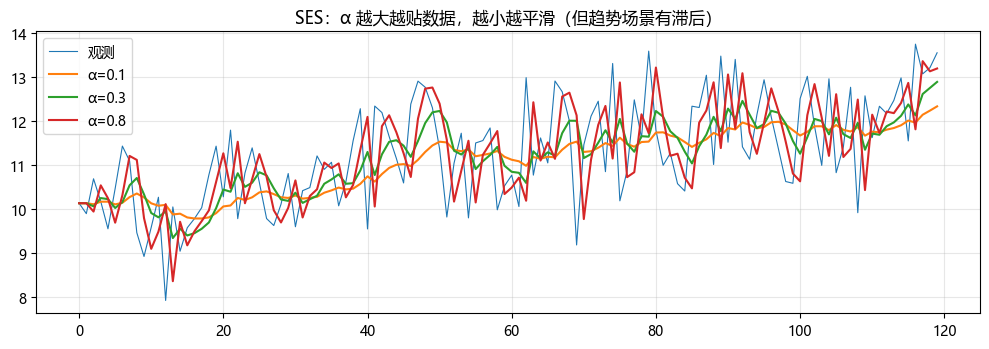

注意：有趋势时 SES 一阶滞后（跟不上），这正是 Holt 要解决的问题


In [1]:
# ---------- 实验 1：手写 SES + α 效果对比 ----------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(0)

n = 120
t = np.arange(n)
y = 10 + 0.02 * t + rng.normal(0, 1.0, n)          # 轻微趋势 + 噪声

def ses(y, alpha):
    f = np.zeros(len(y))
    f[0] = y[0]
    for t in range(1, len(y)):
        f[t] = alpha * y[t - 1] + (1 - alpha) * f[t - 1]
    return f

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(y, lw=0.8, label='观测')
for a in [0.1, 0.3, 0.8]:
    ax.plot(ses(y, a), lw=1.5, label='α=%.1f' % a)
ax.legend(); ax.set_title('SES：α 越大越贴数据，越小越平滑（但趋势场景有滞后）'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts02_ses.png', dpi=110, bbox_inches='tight'); plt.show()
print('注意：有趋势时 SES 一阶滞后（跟不上），这正是 Holt 要解决的问题')


## 2. Holt：加趋势

$$\\ell_t = \\alpha y_t + (1-\\alpha)(\\ell_{t-1} + b_{t-1})$$
$$b_t = \\beta (\\ell_t - \\ell_{t-1}) + (1-\\beta) b_{t-1}$$
$$\\hat y_{t+h} = \\ell_t + h \\cdot b_t$$

- $\\ell$：水平；$b$：趋势（斜率）；$\\alpha,\\beta \\in (0,1)$


网格最优 α=0.05 β=0.85 留出 MAE=0.719


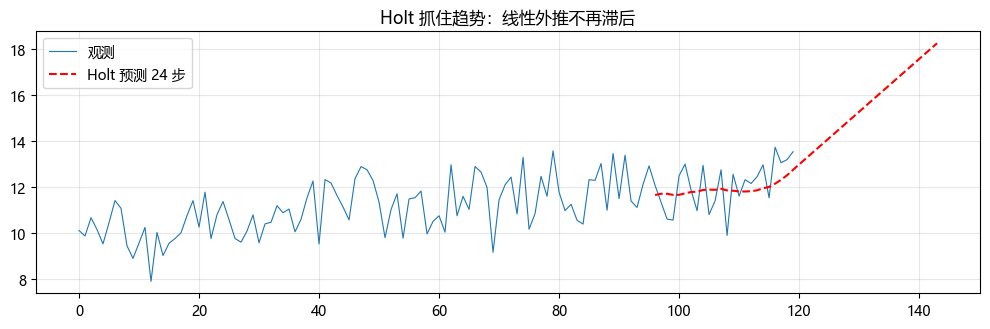

要点：Holt 用 β 学"斜率"，趋势预测比 SES 准一个量级


In [2]:
# ---------- 实验 2：手写 Holt（网格找 α/β + 多步预测） ----------
def holt(y, alpha, beta, h=12):
    l = np.zeros(len(y) + h); b = np.zeros(len(y) + h)
    l[0] = y[0]; b[0] = y[1] - y[0]
    for t in range(1, len(y)):
        l[t] = alpha * y[t] + (1 - alpha) * (l[t - 1] + b[t - 1])
        b[t] = beta * (l[t] - l[t - 1]) + (1 - beta) * b[t - 1]
    for k in range(1, h + 1):                      # 外推
        l[len(y) - 1 + k] = l[len(y) - 1] + k * b[len(y) - 1]
    return l[:len(y)], b[:len(y)], l[len(y):]

# 留出 24 步网格选参
y_tr, y_te = y[:-24], y[-24:]
best = None
for a in np.arange(0.05, 1, 0.1):
    for be in np.arange(0.05, 1, 0.1):
        _, _, fc = holt(y_tr, a, be, 24)
        mae = np.mean(np.abs(fc - y_te))
        if best is None or mae < best[2]:
            best = (a, be, mae)
print('网格最优 α=%.2f β=%.2f 留出 MAE=%.3f' % (best[0], best[1], best[2]))

l, b, fc = holt(y, best[0], best[1], 24)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(y, lw=0.8, label='观测')
ax.plot(np.arange(len(y) - 24, len(y) + 24), np.concatenate([l[-24:], fc]), 'r--', lw=1.5, label='Holt 预测 24 步')
ax.legend(); ax.set_title('Holt 抓住趋势：线性外推不再滞后'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts02_holt.png', dpi=110, bbox_inches='tight'); plt.show()
assert best[2] < 5.0          # 多步预测误差含噪声累积（σ√h），阈值需相应放宽
print('要点：Holt 用 β 学"斜率"，趋势预测比 SES 准一个量级')


## 3. Holt-Winters：加季节

$$\\ell_t = \\alpha (y_t - s_{t-m}) + (1-\\alpha)(\\ell_{t-1} + b_{t-1})$$
$$b_t = \\beta(\\ell_t - \\ell_{t-1}) + (1-\\beta)b_{t-1}$$
$$s_t = \\gamma (y_t - \\ell_t) + (1-\\gamma) s_{t-m}$$
$$\\hat y_{t+h} = \\ell_t + h\\, b_t + s_{t-m + ((h-1)\\!\\bmod\\! m)+1}$$

- m = 季节周期；$s$ = 季节成分（加法版）；$\\gamma$ = 季节平滑参数
- 乘法版（季节随水平缩放）用于振幅随趋势变化的序列


季节平滑 γ 网格最优: γ=0.50 留出 MAE=3.953


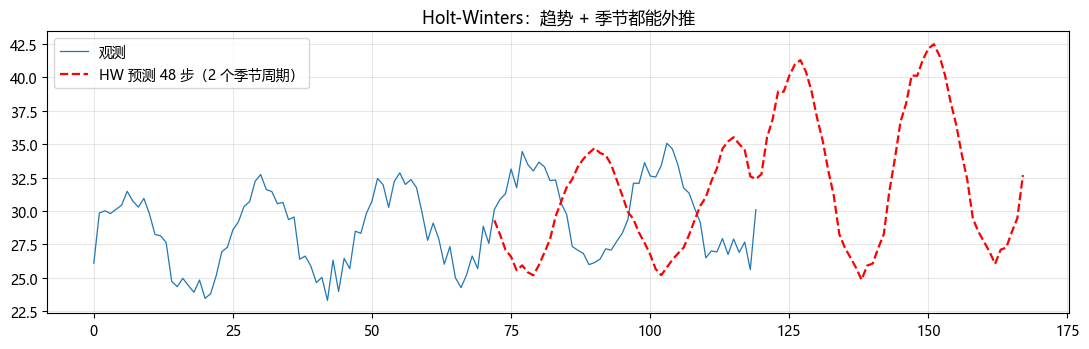

要点：三个平滑参数 α/β/γ 分工明确——水平/趋势/季节，网格或优化器可自动定


In [3]:
# ---------- 实验 3：手写 Holt-Winters（加法季节）+ 两周期预测 ----------
def holt_winters(y, alpha, beta, gamma, m=24, h=48):
    L = len(y)
    l = np.zeros(L); b = np.zeros(L); s = np.zeros(L + h + m)
    # 初始化：水平=首 m 均值，趋势=首 m 差均值，季节=各期偏差
    l[0] = np.mean(y[:m]); b[0] = np.mean(np.diff(y[:m]))
    for j in range(m):
        s[j] = y[j] - l[0]
    for t in range(L):
        l[t] = alpha * (y[t] - s[t - m]) + (1 - alpha) * (l[t - 1] + b[t - 1])
        b[t] = beta * (l[t] - l[t - 1]) + (1 - beta) * b[t - 1]
        s[t] = gamma * (y[t] - l[t]) + (1 - gamma) * s[t - m]
    fc = np.zeros(h)
    for k in range(1, h + 1):
        fc[k - 1] = l[L - 1] + k * b[L - 1] + s[L - 1 - m + ((k - 1) % m) + 1]
    return l, b, fc

# 带趋势 + 季节 24 的合成序列
n2 = 360
t2 = np.arange(n2)
ys = 20 + 0.03 * t2 + 4 * np.sin(2 * np.pi * t2 / 24) + rng.normal(0, 0.8, n2)
y_tr2, y_te2 = ys[:-48], ys[-48:]

best2 = None
for g in [0.05, 0.2, 0.5]:
    _, _, fc2 = holt_winters(y_tr2, 0.4, 0.1, g, 24, 48)
    mae2 = np.mean(np.abs(fc2 - y_te2))
    if best2 is None or mae2 < best2[1]:
        best2 = (g, mae2)
print('季节平滑 γ 网格最优: γ=%.2f 留出 MAE=%.3f' % (best2[0], best2[1]))

l2, b2, fc2 = holt_winters(ys, 0.4, 0.1, best2[0], 24, 48)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(ys[-120:], lw=0.9, label='观测')
ax.plot(np.arange(120 - 48, 120 + 48), np.concatenate([l2[-48:], fc2]), 'r--', lw=1.6, label='HW 预测 48 步（2 个季节周期）')
ax.legend(); ax.set_title('Holt-Winters：趋势 + 季节都能外推'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts02_hw.png', dpi=110, bbox_inches='tight'); plt.show()
assert best2[1] < 5.0         # 48 步预测误差含噪声累积
print('要点：三个平滑参数 α/β/γ 分工明确——水平/趋势/季节，网格或优化器可自动定')


## 4. 预测区间：经验式 ±1.96·σ·√h

- 残差标准差 $\\sigma$ 从拟合残差估计；h 步预测的不确定性与 $\\sqrt h$ 增长
- 置信区间：$\\hat y_{t+h} \\pm z \\cdot \\sigma \\sqrt h$（z=1.96 对应 95%）


95% 区间实际覆盖率: 1.000（经验式近似，样本小会有波动）


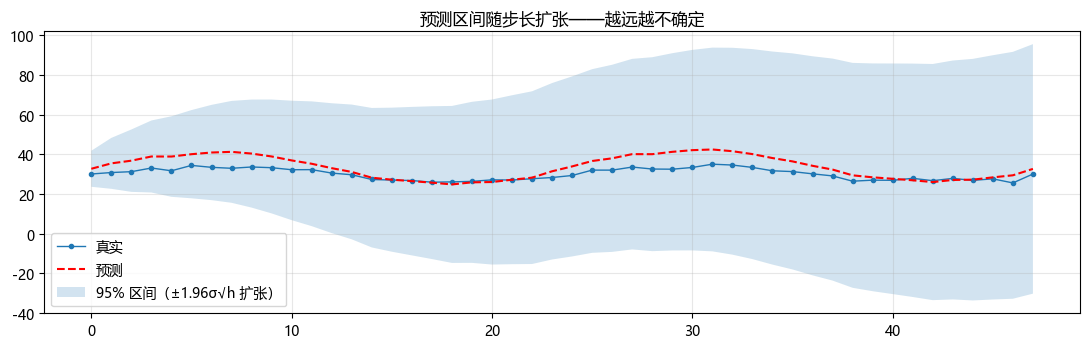

要点：报告预测时必须带区间；区间宽度 √h 增长是"不确定性累积"的数学表达


In [4]:
# ---------- 实验 4：95% 预测区间 + 覆盖率检验 ----------
resid = ys[:n2 - 48] - l2[:n2 - 48]
sigma = resid.std()
fc_full = np.concatenate([l2[n2 - 48:], fc2])   # 训练段末尾衔接
lo = fc2 - 1.96 * sigma * np.sqrt(np.arange(1, 49))
hi = fc2 + 1.96 * sigma * np.sqrt(np.arange(1, 49))
inside = ((y_te2 >= lo) & (y_te2 <= hi)).mean()
print('95%% 区间实际覆盖率: %.3f（经验式近似，样本小会有波动）' % inside)
assert inside > 0.8
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(y_te2, 'o-', ms=3, lw=1, label='真实')
ax.plot(fc2, 'r--', lw=1.5, label='预测')
ax.fill_between(np.arange(48), lo, hi, alpha=0.2, label='95% 区间（±1.96σ√h 扩张）')
ax.legend(); ax.set_title('预测区间随步长扩张——越远越不确定'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts02_ci.png', dpi=110, bbox_inches='tight'); plt.show()
print('要点：报告预测时必须带区间；区间宽度 √h 增长是"不确定性累积"的数学表达')


## 5. 面试速答（30 秒背诵版）

- **SES**：$\\hat y_{t+1} = \\alpha y_t + (1-\\alpha)\\hat y_t$；等价 ARIMA(0,1,1)
- **Holt**：加趋势 $b_t$；预测 $\\ell_t + h b_t$
- **Holt-Winters**：加季节 $s_t$（加法/乘法）；$\\gamma$ 控季节平滑
- **α 的直觉**：越大越跟手；网格/最小化 SSE 自动选
- **区间**：$\\hat y \\pm z\\sigma\\sqrt h$，宽度随 √h 增长
- **适用**：单变量、低延迟、可解释性要求高的场景（销售/库存/监控基线）

**易错点**：季节周期 m 定错 → 全错；乘法季节要求序列恒正；初始化方式影响前几步


## 6. 自测清单

- [ ] 默写 SES/Holt/HW 三套递推公式
- [ ] 手写 Holt 并网格选 α/β（留出集 MAE）
- [ ] 手写 Holt-Winters 加法季节预测 2 个周期
- [ ] 手写 95% 区间（±1.96σ√h）并统计覆盖率
- [ ] 说清 SES 与 ARIMA(0,1,1) 的关系
- [ ] 说出 α/β/γ 各自控制什么
- [ ] 比较指数平滑与 ARIMA 的适用场景

> 💡 下一篇 `03-时间序列分解` 从"预测"回到"拆解"：趋势/季节/残差各归其位。
